In [36]:
# Minimal FEniCSx: 1D diffusion with time-dependent reaction, backward Euler
from mpi4py import MPI
from petsc4py import PETSc
import numpy as np
import pyvista 

import ufl
from dolfinx import mesh, fem, plot
from dolfinx.fem.petsc import (
    create_vector, assemble_vector, assemble_matrix, apply_lifting, set_bc
)

# --- Mesh and function space ---
N = 100  # number of cells (1D)
domain = mesh.create_interval(MPI.COMM_WORLD, N, [0.0, 1.0])
V = fem.functionspace(domain, ("CG", 1))


dofs_x0 = fem.locate_dofs_geometrical(V, lambda x: np.isclose(x[0], 0.0))
idx_x0 = int(dofs_x0[0])
times, conc_x0 = [], []

# --- Create facet tags --- 
tdim = domain.topology.dim 
fdim = tdim - 1

facets_left = mesh.locate_entities(domain, fdim, lambda x: np.isclose(x[0], 0.0))
facets_right = mesh.locate_entities(domain, fdim, lambda x: np.isclose(x[0], 1.0))

facet_indices = np.concatenate([facets_left, facets_right])
facet_tags = np.concatenate([np.full_like(facets_left, 1), np.full_like(facets_right, 2)])

mt = mesh.meshtags(domain, fdim, facet_indices, facet_tags)
dx = ufl.Measure("dx", domain=domain)
ds = ufl.Measure("ds", domain=domain, subdomain_data=mt)


# --- Simulation parameters ---
tau = fem.Constant(domain, PETSc.ScalarType(1.0))
gamma = fem.Constant(domain, PETSc.ScalarType(1.0))
chi_ = fem.Constant(domain, PETSc.ScalarType(0.1))

# --- Trial/test  ---
u  = ufl.TrialFunction(V)
v  = ufl.TestFunction(V)

# --- Time stepping parameters ---
dt = 1e-2
t0, t_end = 0.0, 1.0
num_steps = int(np.ceil((t_end - t0) / dt))
t = t0

# --- Initial condition C(x,0) ---
u_n = fem.Function(V, name="C_prev")

# Example: a smooth bump; replace with your data if desired
x = V.tabulate_dof_coordinates()[:, 0]
tau_, gamma_, chi_star = 2.0, 2.0, 0.1
u_n.x.array[:] = chi_star + (1-chi_star)/(1 + (tau_/gamma_)*np.tanh(tau_))*(np.cosh(tau_*(x - 1)))/(np.cosh(tau_))
u_n.x.scatter_forward()

# --- Time-dependent reaction coefficient k(x,t) ---
k_fun = fem.Function(V, name="kappa")
d_fun = fem.Function(V, name="delta")

def update_k(k_fun, t):
    #k0, T = 5.0, 0.02
    vals = np.ones_like(x)
    k_fun.x.array[:] = vals
    k_fun.x.scatter_forward()

def update_d(d_fun, t):
    vals = np.ones_like(x)
    d_fun.x.array[:] = vals
    d_fun.x.scatter_forward()

def update_boundary(t):
    # e.g. gamma.value = PETSc.ScalarType( some np function of t)
    pass

# --- Boundary conditions (choose one block) ---
# Option A (default here): homogeneous Neumann on both ends (natural for Laplacian).
# --> No Dirichlet BC objects needed; just leave `bcs = []`.
bcs = []

# --- Variational forms (backward Euler) ---
k = k_fun  # alias for UFL
d = d_fun  # alias for UFL
a_form =      u*v*dx \
         + dt*u*v*tau**2*k*dx \
         + dt*d*ufl.inner(ufl.grad(u), ufl.grad(v))*dx \
         + dt*gamma*u*v*ds(1)
L_form =      u_n*v*dx \
         + dt*tau**2*k*chi_*v*dx \
         + dt*gamma*v*ds(1)


a = fem.form(a_form)
L = fem.form(L_form)

# Pre-create PETSc objects with the correct sparsity pattern
A = fem.petsc.create_matrix(a)
b = create_vector(L)

# Linear solver
ksp = PETSc.KSP().create(MPI.COMM_WORLD)
ksp.setType("cg")          # SPD for this model (with Dirichlet or pure Neumann + mass term)
ksp.getPC().setType("hypre")
ksp.setTolerances(rtol=1e-10, atol=1e-12, max_it=500)

# Solution function at new time
u_new = fem.Function(V, name="C")






# --- plotting ---
grid = pyvista.UnstructuredGrid(*plot.vtk_mesh(V))
xcoords = grid.points[:, 0].copy()
warp_factor = 1.0 
z_offset = 1e-6

def update_points_from_solution(u_array):
    y = warp_factor * u_array
    new_points = np.c_[xcoords, y, np.zeros_like(xcoords)]
    return new_points

grid.point_data["uh"] = u_new.x.array.copy()
grid.points = update_points_from_solution(grid.point_data["uh"])

clim = (0.0, 1.0)
plotter = pyvista.Plotter(window_size=(500,400))
plotter.open_gif("u_time.gif", fps=10)
actor = plotter.add_mesh(
    grid,
    show_edges=True,
    lighting=False,
    show_scalar_bar=False,
    clim=clim,
    line_width=4
)


def f_equilibrium(x, tau_=1.0, gamma_=1.0, chi_star=0.1):
    return chi_star + (1-chi_star)/(1 + (tau_/gamma_)*np.tanh(tau_))*(np.cosh(tau_*(x - 1)))/(np.cosh(tau_))

equilibrium = grid.copy(deep=True)
equilibrium_y = warp_factor * f_equilibrium(xcoords)
equilibrium.points = np.c_[xcoords, equilibrium_y, np.zeros_like(xcoords)]

equilibrium_actor = plotter.add_mesh(
    equilibrium,
    color="black",
    show_edges=False,
    line_width=2,
    lighting=False
)

xmin, xmax = 0.0, 1.0
umin, umax = warp_factor * 0.0, warp_factor * 1.0
bounds_2d = (xmin, xmax, umin, umax, 0.0, 0.0)
cube = plotter.show_grid(
    bounds=bounds_2d,
    location="outer",
    xtitle="x",
    ytitle="C(x,t)",
    ticks="both",
    font_size=2,
    grid="both",
)
cube.SetLabelOffset(4)

xmid = 0.5 * (xmin + xmax)
ymid = 0.5 * (umin + umax)
plotter.view_xy()
plotter.camera.parallel_projection = True
plotter.set_focus((xmid, ymid, 0.0))
plotter.set_position((xmid, ymid, 10.0))
plotter.camera.SetParallelScale(0.5)
plotter.camera.zoom(0.8)

plotter.write_frame()

k0s = []

# --- Time loop ---
for step in range(num_steps):
    t += dt

    # Update k(x,t)
    update_k(k_fun, t)
    update_d(d_fun, t)
    update_boundary(t)

    # Reassemble A and b because k is time-dependent
    A.zeroEntries()
    assemble_matrix(A, a, bcs)
    A.assemble()

    with b.localForm() as b_loc:
        b_loc.set(0.0)
    assemble_vector(b, L)
    apply_lifting(b, [a], [bcs])      # accounts for Dirichlet on RHS if present
    b.ghostUpdate(addv=PETSc.InsertMode.ADD, mode=PETSc.ScatterMode.REVERSE)
    set_bc(b, bcs)                    # enforce Dirichlet values in RHS

    # Solve A * x = b
    ksp.setOperators(A)
    ksp.solve(b, u_new.x.petsc_vec)
    u_new.x.petsc_vec.ghostUpdate(addv=PETSc.InsertMode.INSERT,
                             mode=PETSc.ScatterMode.FORWARD)

    # Prepare for next step
    u_n.x.array[:] = u_new.x.array
    u_n.x.scatter_forward()

    # --- plotting update ---
    grid.point_data["uh"][:] = u_new.x.array 
    grid.points[:,:] = update_points_from_solution(u_new.x.array)
    plotter.write_frame()

    # extract chi_i
    conc_x0.append(u_new.x.array[idx_x0])
    times.append(t)
    k0s.append(k_fun.x.array[idx_x0])

plotter.close()
A.destroy()
b.destroy()
ksp.destroy()

data = np.vstack([times, conc_x0, k0s]).T
np.savetxt("concentration_x0_vs_time.txt", data, delimiter=";")




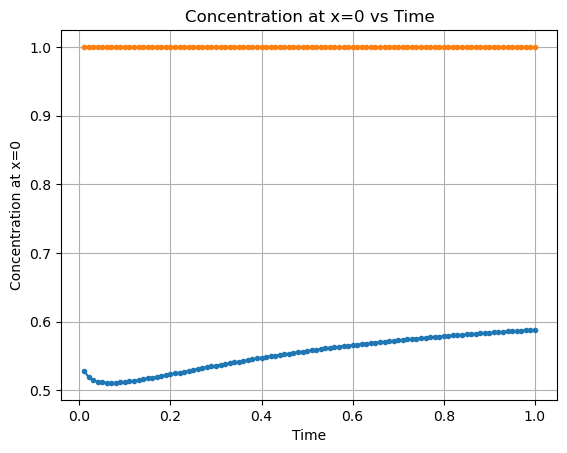

In [37]:
data = np.loadtxt("concentration_x0_vs_time.txt", delimiter=";")
time, conc_x0, k0s = data[:,0], data[:,1], data[:,2]
import matplotlib.pyplot as plt
plt.plot(time, conc_x0, marker=".")
plt.plot(time, k0s, marker=".")
plt.xlabel("Time")
plt.ylabel("Concentration at x=0")
plt.title("Concentration at x=0 vs Time")
plt.grid()
plt.show()